# Setting

In [6]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from api import split_expand
from langchain_openai import ChatOpenAI


llm4o = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o',
    temperature=1,
)

llm = ChatOpenAI(
    openai_api_key = os.getenv('OPENAI_API_KEY'),
    model='gpt-4o-mini',
    temperature=1,
)

# 買進賣出需要的手續費
fee = {
    'tax_stock' : 0.003,          # 買進與賣出各0.003
    'tax_future' : 0.00002 * 2,   # 買進與賣出各0.00002
    'fee_stock' : 0.001425 * 2,   # 券商手續費公道價，買進與賣出各0.001425
    'fee_future' : 0.00002 * 2,   # 個家不大相同，以交易稅計算
    'sliding_price' : 0.00001,    # 滑價
}

data = [
    ["2330", "台積電", "tw"],
    ["2317", "鴻海", "tw"],
    ["2454", "聯發科", "tw"],
    ["2382", "廣達", "tw"],
    ["3231", "緯創", "tw"],
    # ["2324","仁寶", "tw"],
    # ["4938", "和碩", "tw"],
    # ["2356","英業達", "tw"],
    # ["2881", "富邦金", "tw"],
    # ["2882", "國泰金", "tw"],
    # ["2412", "中華電", "tw"],
    # ["3045", "台灣大", "tw"],
    # ["6505", "台塑化", "tw"],
    # ["2603", "長榮", "tw"],
    
    ["AAPL", "Apple Inc.", "us"],
    ["GOOGL", "Google", "us"],
    ["MSFT", "Microsoft", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["TSLA", "Tesla", "us"],
    ["NVDA", "Nvidia", "us"],
    # ["META", "Meta Platforms", "us"],
    # ["BRK", "Berkshire Hathaway", "us"],
]

date_ranges = [
    ["20230401", "20240331"],
    ["20230701", "20240630"],
    ["20231001", "20240930"],
]

# env = {
#     "stock_id" : "NVDA",
#     "stock_name" : "Nvidia",
#     "country" : "us",
#     "start_date" : "20230401",
#     "end_date" : "20240331",
# }


# 換一種評分作法，正面就持續持有，負面就賣出
# 只跑有用的factor
def get_balance_list(list_rtn, start_price):
    balance = start_price
    list_balance = []
    for rtn in list_rtn:
        balance = balance * (1 + float(rtn))
        list_balance.append(balance)
    return list_balance

2330 台積電 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,61,61,38,25,185,185,0.535135,0.500000,0.709302,0.001616,0.000949,"[[20230406, 0.0], [20230407, 0.007476635514018...","[[20230406, 0.0], [20230407, 0.009433962264150..."
test,22,26,7,1,56,56,0.517857,0.458333,0.956522,0.001986,0.000941,"[[20240102, 0.005084745762711864], [20240103, ...","[[20240102, 0.005084745762711864], [20240103, ..."


2330 台積電 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,72,74,22,14,182,182,0.516484,0.493151,0.837209,0.001138,0.000681,"[[20230703, -0.0017301038062283738], [20230704...","[[20230703, -0.0017301038062283738], [20230704..."
test,27,20,11,3,61,61,0.622951,0.574468,0.900000,0.004595,0.003718,"[[20240401, -0.016602809706257982], [20240402,...","[[20240401, -0.016602809706257982], [20240402,..."


2330 台積電 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,81,70,19,10,180,180,0.555556,0.536424,0.89011,0.002333,0.001783,"[[20231002, 0.005660377358490566], [20231003, ...","[[20231002, 0.005660377358490566], [20231003, ..."
test,26,22,10,5,63,63,0.571429,0.541667,0.83871,0.004054,0.003256,"[[20240701, 0.0], [20240702, 0.007238883143743...","[[20240701, 0.0], [20240702, -0.00103305785123..."


180 180 180 180


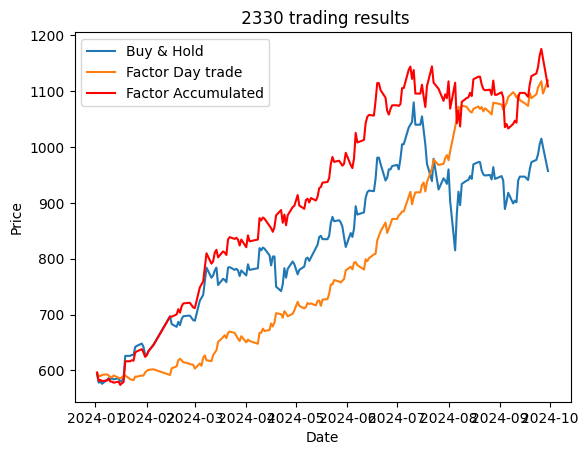

2317 鴻海 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,31,51,48,55,185,185,0.427027,0.378049,0.360465,0.001434,0.000458,"[[20230406, 0.009569377990430622], [20230407, ...","[[20230406, 0.009569377990430622], [20230407, ..."
test,13,14,12,17,56,56,0.446429,0.481481,0.433333,0.004427,0.008026,"[[20240102, -0.004784688995215311], [20240103,...","[[20240102, -0.004784688995215311], [20240103,..."


2317 鴻海 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,45,63,37,36,181,182,0.453039,0.416667,0.555556,0.002029,0.001688,"[[20230703, 0.008771929824561403], [20230704, ...","[[20230703, 0.008771929824561403], [20230704, ..."
test,19,24,9,9,61,61,0.459016,0.441860,0.678571,0.003714,0.004955,"[[20240401, -0.0033112582781456954], [20240402...","[[20240401, -0.0033112582781456954], [20240402..."


2317 鴻海 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,41,39,45,55,180,180,0.477778,0.512500,0.427083,0.004130,0.006891,"[[20231002, -0.004807692307692308], [20231003,...","[[20231002, -0.004807692307692308], [20231003,..."
test,16,12,23,12,63,63,0.619048,0.571429,0.571429,0.005945,0.004825,"[[20240701, 0.004651162790697674], [20240702, ...","[[20240701, 0.004651162790697674], [20240702, ..."


180 180 180 180


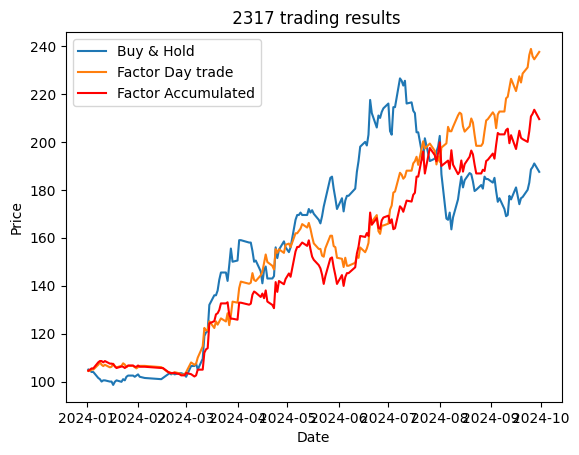

2454 聯發科 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,48,60,43,34,185,185,0.491892,0.444444,0.585366,0.001489,0.001097,"[[20230406, 0.027131782945736434], [20230407, ...","[[20230406, 0.027131782945736434], [20230407, ..."
test,17,21,12,6,56,56,0.517857,0.447368,0.739130,0.004634,0.002934,"[[20240102, 0.028712871287128714], [20240103, ...","[[20240102, 0.028712871287128714], [20240103, ..."


2454 聯發科 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,70,78,27,7,182,182,0.532967,0.472973,0.909091,0.003059,0.001841,"[[20230703, -0.001445086705202312], [20230704,...","[[20230703, -0.001445086705202312], [20230704,..."
test,23,25,8,5,61,61,0.508197,0.479167,0.821429,0.003015,0.001430,"[[20240401, -0.025210084033613446], [20240402,...","[[20240401, -0.025210084033613446], [20240402,..."


2454 聯發科 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,72,76,22,10,180,180,0.522222,0.486486,0.878049,0.003672,0.002160,"[[20231002, 0.002677376171352075], [20231003, ...","[[20231002, 0.002677376171352075], [20231003, ..."
test,16,21,16,10,63,63,0.507937,0.432432,0.615385,0.003284,0.003697,"[[20240701, 0.0071174377224199285], [20240702,...","[[20240701, 0.0071174377224199285], [20240702,..."


180 180 180 180


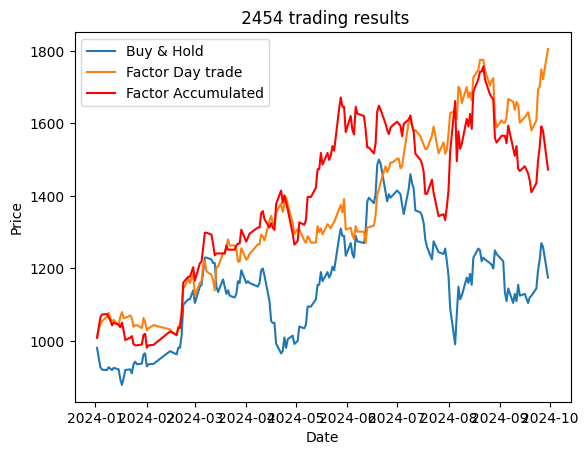

2382 廣達 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,81,73,18,13,185,185,0.535135,0.525974,0.861702,0.004345,0.003465,"[[20230406, 0.00897867564534244], [20230407, 0...","[[20230406, 0.00897867564534244], [20230407, -..."
test,24,22,7,3,56,56,0.553571,0.521739,0.888889,0.001870,0.000439,"[[20240102, -0.0467706013363029], [20240103, -...","[[20240102, -0.0467706013363029], [20240103, -..."


2382 廣達 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,58,60,35,29,182,182,0.510989,0.491525,0.666667,0.003269,0.002337,"[[20230703, 0.035483870967741936], [20230704, ...","[[20230703, 0.035483870967741936], [20230704, ..."
test,18,30,4,9,61,61,0.360656,0.375000,0.666667,-0.004102,-0.003884,"[[20240401, 0.04074702886247878], [20240402, 0...","[[20240401, 0.04074702886247878], [20240402, -..."


2382 廣達 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,28,23,74,55,180,180,0.566667,0.549020,0.337349,0.004407,0.003262,"[[20231002, -0.03877551020408163], [20231003, ...","[[20231002, -0.03877551020408163], [20231003, ..."
test,13,6,27,17,63,63,0.634921,0.684211,0.433333,0.008390,0.009149,"[[20240701, 0.01437699680511182], [20240702, 0...","[[20240701, 0.01437699680511182], [20240702, 0..."


180 180 180 180


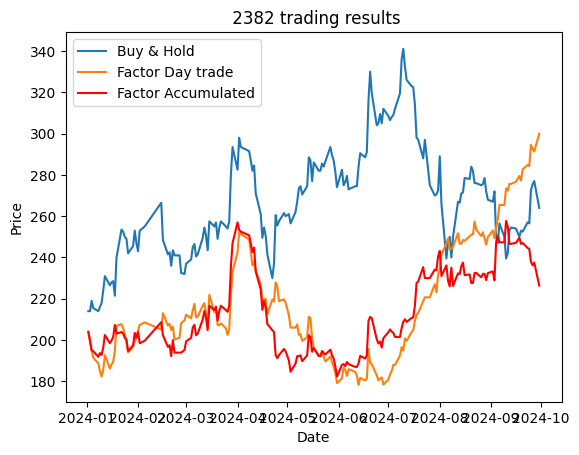

3231 緯創 tw 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,87,91,7,0,185,185,0.508108,0.488764,1.000000,0.005249,0.003549,"[[20230406, 0.0], [20230407, -0.02168674698795...","[[20230406, 0.0], [20230407, -0.01932367149758..."
test,23,31,1,1,56,56,0.428571,0.425926,0.958333,-0.003028,-0.003603,"[[20240102, -0.04969574036511148], [20240103, ...","[[20240102, -0.04969574036511148], [20240103, ..."


3231 緯創 tw 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,65,80,21,16,182,182,0.472527,0.448276,0.802469,0.000905,-0.001275,"[[20230703, 0.02243589743589753], [20230704, 0...","[[20230703, 0.02243589743589753], [20230704, 0..."
test,13,33,11,4,61,61,0.393443,0.282609,0.764706,-0.000425,-0.004506,"[[20240401, -0.03543307086614173], [20240402, ...","[[20240401, -0.03543307086614173], [20240402, ..."


3231 緯創 tw 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,5,10,98,67,180,180,0.572222,0.333333,0.069444,0.005822,0.00344,"[[20231002, -0.0673076923076923], [20231003, 0...","[[20231002, -0.0673076923076923], [20231003, 0..."
test,0,7,33,23,63,63,0.523810,0.000000,0.000000,-0.000575,0.00000,"[[20240701, -0.009389671361502348], [20240702,...","[[20240701, -0.009389671361502348], [20240702,..."


180 180 180 180


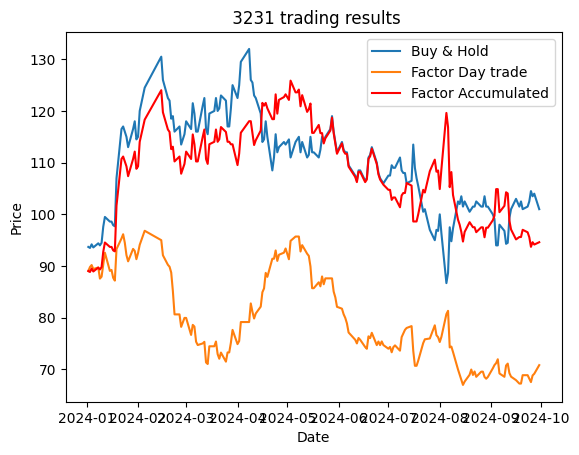

AAPL Apple Inc. us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,74,48,30,36,188,188,0.553191,0.606557,0.672727,0.001287,0.001840,"[[20230403, 0.011566323735313673], [20230404, ...","[[20230403, 0.011566323735313673], [20230404, ..."
test,13,17,16,15,61,61,0.475410,0.433333,0.464286,-0.000280,0.000042,"[[20240102, -0.008068394336094145], [20240103,...","[[20240102, -0.008068394336094145], [20240103,..."


AAPL Apple Inc. us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,56,50,38,43,187,187,0.502674,0.528302,0.565657,0.000320,0.000622,"[[20230703, -0.00681184848797602], [20230705, ...","[[20230703, -0.00681184848797602], [20230705, ..."
test,22,25,10,6,63,63,0.507937,0.468085,0.785714,-0.000982,-0.000564,"[[20240401, 0.00677609673462233], [20240402, 0...","[[20240401, 0.00677609673462233], [20240402, 0..."


AAPL Apple Inc. us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,56,44,47,40,187,187,0.550802,0.560000,0.583333,0.000890,0.001801,"[[20231002, 0.014776311178600638], [20231003, ...","[[20231002, 0.014776311178600638], [20231003, ..."
test,24,15,11,14,64,64,0.546875,0.615385,0.631579,-0.000777,0.000695,"[[20240701, 0.021971804422650745], [20240702, ...","[[20240701, 0.021971804422650745], [20240702, ..."


188 188 188 188


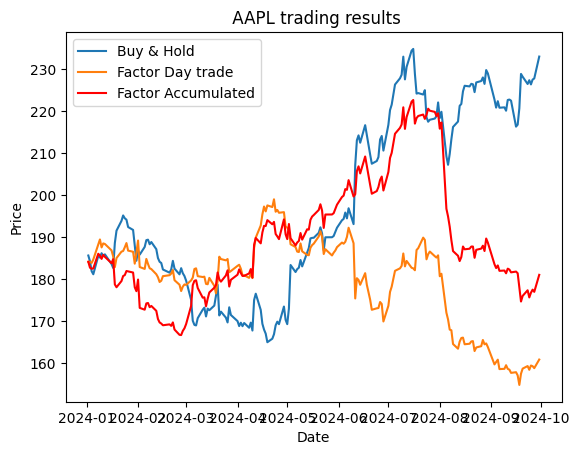

GOOGL Google us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,51,31,54,52,188,188,0.558511,0.621951,0.495146,0.001817,0.003900,"[[20230403, 0.019240160171891774], [20230404, ...","[[20230403, 0.019240160171891774], [20230404, ..."
test,8,7,18,28,61,61,0.426230,0.533333,0.222222,-0.000153,0.001606,"[[20240102, 0.002742692168892269], [20240103, ...","[[20240102, 0.002742692168892269], [20240103, ..."


GOOGL Google us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,39,24,60,64,187,187,0.529412,0.619048,0.378641,0.001815,0.004038,"[[20230703, 0.005535055350553596], [20230705, ...","[[20230703, 0.005535055350553596], [20230705, ..."
test,11,10,10,32,63,63,0.333333,0.523810,0.255814,-0.002690,0.000409,"[[20240401, 0.03185347401951033], [20240402, -...","[[20240401, 0.03185347401951033], [20240402, -..."


GOOGL Google us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,40,25,50,72,187,187,0.481283,0.615385,0.357143,0.000864,0.003933,"[[20231002, 0.022559256154256378], [20231003, ...","[[20231002, 0.022559256154256378], [20231003, ..."
test,15,13,20,16,64,64,0.546875,0.535714,0.483871,0.000304,-0.002165,"[[20240701, -0.00021854340818440714], [2024070...","[[20240701, -0.00021854340818440714], [2024070..."


188 188 188 188


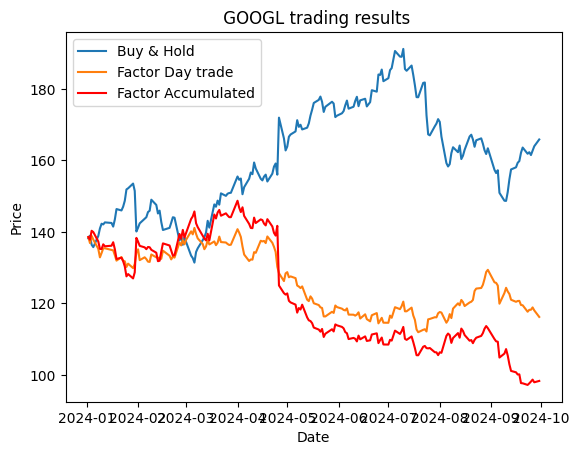

MSFT Microsoft us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,55,46,41,46,188,188,0.510638,0.544554,0.544554,-0.000316,0.000248,"[[20230403, 0.002478012006142805], [20230404, ...","[[20230403, 0.002478012006142805], [20230404, ..."
test,21,24,6,10,61,61,0.442623,0.466667,0.677419,-0.001976,-0.000901,"[[20240102, -0.007997646177713607], [20240103,...","[[20240102, -0.007997646177713607], [20240103,..."


MSFT Microsoft us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,75,73,16,23,187,187,0.486631,0.506757,0.765306,0.000134,0.000184,"[[20230703, 0.003537840148589253], [20230705, ...","[[20230703, 0.003537840148589253], [20230705, ..."
test,32,18,7,6,63,63,0.619048,0.640000,0.842105,0.000180,0.000144,"[[20240401, -0.0014624366080905876], [20240402...","[[20240401, -0.0014624366080905876], [20240402..."


MSFT Microsoft us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,82,65,16,24,187,187,0.524064,0.557823,0.773585,0.000068,0.000530,"[[20231002, 0.01745288984444176], [20231003, 0...","[[20231002, 0.01745288984444176], [20231003, -..."
test,19,20,13,12,64,64,0.500000,0.487179,0.612903,0.000521,-0.000781,"[[20240701, 0.01798689430749341], [20240702, 0...","[[20240701, 0.01798689430749341], [20240702, 0..."


188 188 188 188


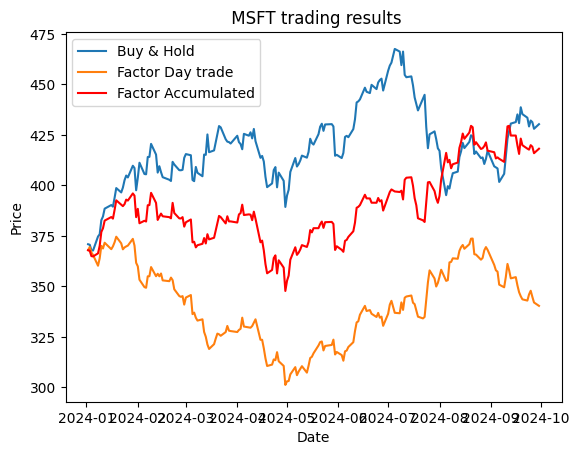

AMZN Amazon inc. us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,46,42,43,57,188,188,0.473404,0.522727,0.446602,-0.001166,-0.000368,"[[20230403, -0.0010752688172042957], [20230404...","[[20230403, -0.0010752688172042957], [20230404..."
test,20,15,10,16,61,61,0.491803,0.571429,0.555556,0.000068,0.001584,"[[20240102, 0.010624257621749936], [20240103, ...","[[20240102, 0.010624257621749936], [20240103, ..."


AMZN Amazon inc. us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,69,61,22,34,186,187,0.489247,0.530769,0.669903,-0.000625,0.000131,"[[20230703, -0.004586454670539629], [20230705,...","[[20230703, -0.004586454670539629], [20230705,..."
test,28,26,4,5,63,63,0.507937,0.518519,0.848485,-0.000320,-0.000309,"[[20240401, 0.0009956302892859495], [20240402,...","[[20240401, 0.0009956302892859495], [20240402,..."


AMZN Amazon inc. us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,64,53,27,43,187,187,0.486631,0.547009,0.598131,-0.000011,0.001006,"[[20231002, -0.017127592708988112], [20231003,...","[[20231002, -0.017127592708988112], [20231003,..."
test,16,26,11,11,64,64,0.421875,0.380952,0.592593,-0.001627,-0.002462,"[[20240701, -0.019174117525453404], [20240702,...","[[20240701, -0.019174117525453404], [20240702,..."


188 188 188 188


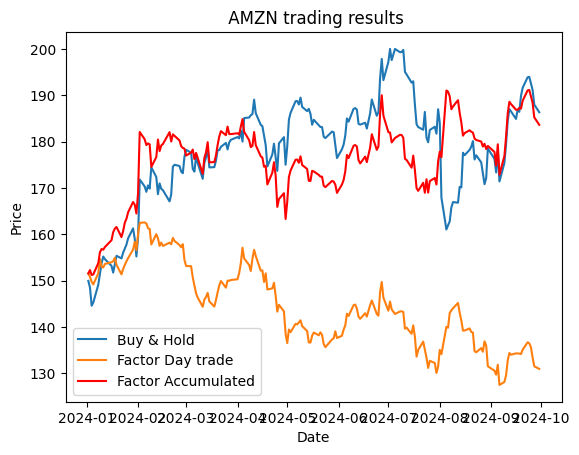

TSLA Tesla us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,43,32,54,59,188,188,0.515957,0.573333,0.421569,0.001543,0.003246,"[[20230403, -0.0257115702065929], [20230404, 0...","[[20230403, -0.0257115702065929], [20230404, 0..."
test,4,7,27,23,61,61,0.508197,0.363636,0.148148,0.000652,-0.002504,"[[20240102, 0.00663787587971859], [20240103, 0...","[[20240102, 0.00663787587971859], [20240103, 0..."


TSLA Tesla us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,30,25,70,62,187,187,0.534759,0.545455,0.326087,0.001857,0.001856,"[[20230703, 0.012043835220080235], [20230705, ...","[[20230703, 0.012043835220080235], [20230705, ..."
test,1,3,30,29,63,63,0.492063,0.250000,0.033333,-0.002322,-0.009307,"[[20240401, -0.005392518589998233], [20240402,...","[[20240401, -0.005392518589998233], [20240402,..."


TSLA Tesla us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,17,15,81,74,187,187,0.524064,0.531250,0.186813,0.001229,0.003411,"[[20231002, 0.027735795106409018], [20231003, ...","[[20231002, 0.027735795106409018], [20231003, ..."
test,13,4,24,23,64,64,0.578125,0.764706,0.361111,0.002606,0.009801,"[[20240701, -0.04397572380857628], [20240702, ...","[[20240701, -0.04397572380857628], [20240702, ..."


188 188 188 188


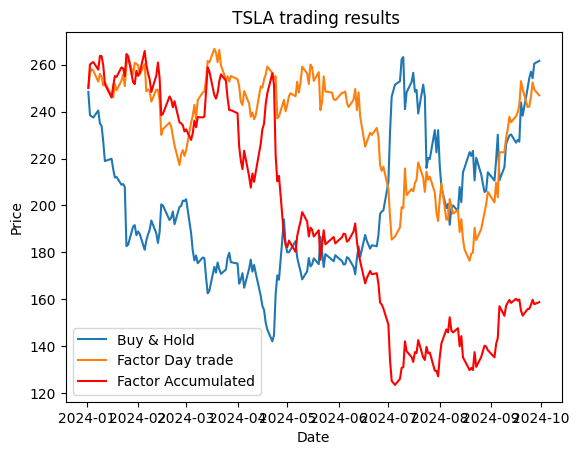

NVDA Nvidia us 20230401 20240331


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,74,66,25,23,188,188,0.526596,0.528571,0.762887,0.002075,0.001857,"[[20230403, -0.016576393180413665], [20230404,...","[[20230403, -0.016576393180413665], [20230404,..."
test,28,22,3,8,61,61,0.508197,0.560000,0.777778,-0.000819,0.001657,"[[20240102, -0.02185037771099018], [20240103, ...","[[20240102, -0.02185037771099018], [20240103, ..."


NVDA Nvidia us 20230701 20240630


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,76,64,23,24,187,187,0.529412,0.542857,0.760000,0.001102,0.001390,"[[20230703, 0.002446080391373011], [20230705, ...","[[20230703, 0.002446080391373011], [20230705, ..."
test,24,22,6,11,63,63,0.476190,0.521739,0.685714,-0.001527,-0.000959,"[[20240401, 0.0007087564646340817], [20240402,...","[[20240401, 0.0007087564646340817], [20240402,..."


NVDA Nvidia us 20231001 20240930


,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list,accumulated_rtn_list
train,67,55,26,39,187,187,0.497326,0.549180,0.632075,-0.000142,0.001182,"[[20231002, 0.017079264138087562], [20231003, ...","[[20231002, 0.017079264138087562], [20231003, ..."
test,19,18,14,13,64,64,0.515625,0.513514,0.593750,-0.001542,-0.002371,"[[20240701, -0.006722280715963378], [20240702,...","[[20240701, -0.006722280715963378], [20240702,..."


188 188 188 188


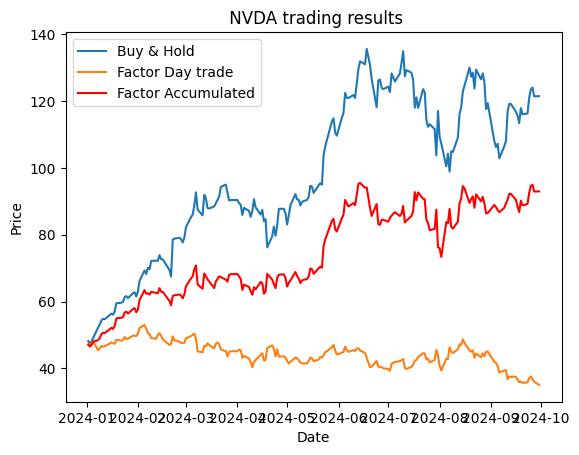

In [7]:
from factor import StockFactor


for stock in data:
    list_date, list_bnh_rtn, list_daytrade_rtn, list_accumulated_rtn = [], [], [], []
    for date_range in date_ranges:
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date" : date_range[0],
            "end_date" : date_range[1],
        }
        print(env['stock_id'], env['stock_name'], env['country'], env['start_date'], env['end_date'])

        stock_factor = StockFactor(env)

        stock_factor.generate_factors(llm4o)
        stock_factor.expand_factors(llm_factors=llm)
        train_datarange, test_datarange = stock_factor.split_exp()

        re_run = False # 是否重新訓練，True:刪除原有資料

        mode = 1
        df = stock_factor.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
        display(df)

        # stock_factor.plot_acumulated_return()


        l_date, l_bnh_rtn, l_daytrade_rtn, l_accumulated_rtn = stock_factor.get_return_list()
        list_date.extend(l_date)
        list_bnh_rtn.extend(l_bnh_rtn)
        list_daytrade_rtn.extend(l_daytrade_rtn)
        list_accumulated_rtn.extend(l_accumulated_rtn)

    print(len(list_date), len(list_bnh_rtn), len(list_daytrade_rtn), len(list_accumulated_rtn))
    list_daytrade_balance = get_balance_list(list_daytrade_rtn, list_bnh_rtn[0])
    list_accumulated_balance = get_balance_list(list_accumulated_rtn, list_bnh_rtn[0])

    dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
    plt.title(f" {env['stock_id']} trading results")
    plt.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
    plt.plot(dplot, list_daytrade_balance, label="Factor Day trade")  # orange
    plt.plot(dplot, list_accumulated_balance, label="Factor Accumulated", color='red')  # red

    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

In [8]:
# from factor import StockFactor
# for stock in data:
#     env = {
#         "stock_id" : stock[0],
#         "stock_name" : stock[1],
#         "country" : stock[2],
#         "start_date" : "20230401",
#         "end_date" : "20240331",
#     }
#     print(env['stock_id'], env['stock_name'], env['country'])

#     stock_factor = StockFactor(env)
#     a = stock_factor.get_expand(show_sig=True)
    
#     print(stock_factor.get_individual(mode=1))
    

In [9]:
# from factor import StockFactor

# for stock in data:
#     env = {
#         "stock_id" : stock[0],
#         "stock_name" : stock[1],
#         "country" : stock[2],
#         "start_date" : "20230401",
#         "end_date" : "20240331",
#     }
#     print(env['stock_id'], env['stock_name'], env['country'])
#     path_folder = "out_stock/GA_factor_" 
#     path_out = path_folder + env['start_date'] + "_" + env['end_date'] + "/" + env['stock_id'] + "/"
#     path_factors = f"{path_out}/factors.json"
#     path_result = f"{path_out}/ev/result.json"

#     with open(path_result, 'r') as f:
#         result = json.load(f)
#         individuals = result['individual']
    
#     with open(path_factors , 'r') as f:
#         factors = json.load(f)
#     i = 0
#     for key, value in factors.items():
#         if individuals[i] == 1:
#             print(key, value)
#         i += 1
#     print("")

# Factor

In [ ]:
from factor import StockFactor

for stock in data:
    for date_range in date_ranges[1:]:
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date" : date_range[0],
            "end_date" : date_range[1],
        }
        print(env['stock_id'], env['stock_name'], env['country'], env['start_date'], env['end_date'])

        stock_factor = StockFactor(env)
        
        stock_factor.generate_factors(llm4o)
        stock_factor.expand_factors(llm_factors=llm)
        train_datarange, test_datarange = stock_factor.split_exp()

        re_run = True # 是否重新訓練，True:刪除原有資料

        mode = 1
        df = stock_factor.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
        display(df)

        stock_factor.plot_acumulated_return()

## 顯示所有

In [5]:

import os
import json
import pandas as pd

for date_r in  date_ranges:
    env = {
        "start_date": date_r[0],
        "end_date": date_r[1],
    }

    path_out = f"out_stock/GA_factor_{env['start_date']}_{env['end_date']}/"
    skip_files = {"ac","factors_eng.json", "factors.json", "old_expand", ".DS_Store", "factors.json", "factors1.json", "embeddings.json", "expand.json", "expand1.json", "expand2.json", "clustered_summaries.json"}

    results = []
    index = []

    for folder in os.listdir(path_out):
        if folder in skip_files:
            continue
        folder_path = os.path.join(path_out, folder)
        for file in os.listdir(folder_path):
            if file in skip_files:
                continue
            path = os.path.join(folder_path, file, "result.json")
            with open(path, 'r') as f:
                json_data = json.load(f)
            results.append(json_data['test'])
            index.append(f"{folder}_{file}")

    df = pd.DataFrame(results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                        'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱

    # 計算平均值
    average_row = df[['accuracy', 'precision', 'ev', 'precision_ev']].replace('%', '', regex=True).astype(float).mean()
    df['accuracy'] = df['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df['precision'] = df['precision'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected = df.loc[:, selected_columns]
    df_sorted = df_selected.sort_index()

    display(df_sorted)
    display(average_row)

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,53.85%,64.29%,0.011392,0.017428,26,9,5,5,7
2330_ev,51.92%,47.83%,0.001448,0.000720,52,22,24,5,1
2382_ev,54.90%,51.22%,0.000641,-0.001264,51,21,20,7,3
2454_ev,51.85%,45.95%,0.005052,0.003664,54,17,20,11,6
3231_ev,43.64%,43.40%,-0.002929,-0.003511,55,23,30,1,1
AAPL_ev,47.54%,43.33%,-0.000280,0.000042,61,13,17,16,15
AMZN_ev,51.79%,63.33%,0.000410,0.002475,56,19,11,10,16
GOOGL_ev,42.37%,53.85%,-0.000196,0.001683,59,7,6,18,28
MSFT_ev,45.00%,46.67%,-0.001703,-0.000901,60,21,24,6,9
NVDA_ev,51.67%,57.14%,-0.000706,0.001846,60,28,21,3,8


accuracy        0.495794
ev              0.001268
precision       0.503054
precision_ev    0.001789
dtype: float64

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,44.90%,40.62%,0.003611,0.004776,49,13,19,9,8
2330_ev,62.30%,57.45%,0.004595,0.003718,61,27,20,11,3
2382_ev,39.13%,50.00%,-0.003024,-0.000575,23,5,5,4,9
2454_ev,50.91%,47.62%,0.003373,0.001672,55,20,22,8,5
3231_ev,38.98%,28.89%,-0.000121,-0.003921,59,13,32,10,4
AAPL_ev,50.79%,46.81%,-0.000982,-0.000564,63,22,25,10,6
AMZN_ev,50.79%,51.85%,-0.000320,-0.000309,63,28,26,4,5
GOOGL_ev,33.33%,52.38%,-0.002690,0.000409,63,11,10,10,32
MSFT_ev,61.90%,64.00%,0.000180,0.000144,63,32,18,7,6
NVDA_ev,46.77%,51.11%,-0.002141,-0.001792,62,23,22,6,11


accuracy        0.480929
ev              0.000015
precision       0.468847
precision_ev   -0.000523
dtype: float64

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,62.50%,57.69%,0.006835,0.005697,56,15,11,20,10
2330_ev,56.45%,53.19%,0.003997,0.003165,62,25,22,10,5
2382_ev,64.71%,64.71%,0.009490,0.009058,51,11,6,22,12
2454_ev,54.00%,46.15%,0.004480,0.005279,50,12,14,15,9
3231_ev,53.33%,0.00%,-0.000959,0.000000,60,0,5,32,23
AAPL_ev,54.69%,61.54%,-0.000777,0.000695,64,24,15,11,14
AMZN_ev,42.86%,39.02%,-0.001395,-0.002127,63,16,25,11,11
GOOGL_ev,53.97%,51.85%,0.000175,-0.002557,63,14,13,20,16
MSFT_ev,47.54%,45.95%,0.000158,-0.001345,61,17,20,12,12
NVDA_ev,50.79%,50.00%,-0.001655,-0.002591,63,18,18,14,13


accuracy        0.544457
ev              0.001991
precision       0.496886
precision_ev    0.002279
dtype: float64

2330 台積電 tw


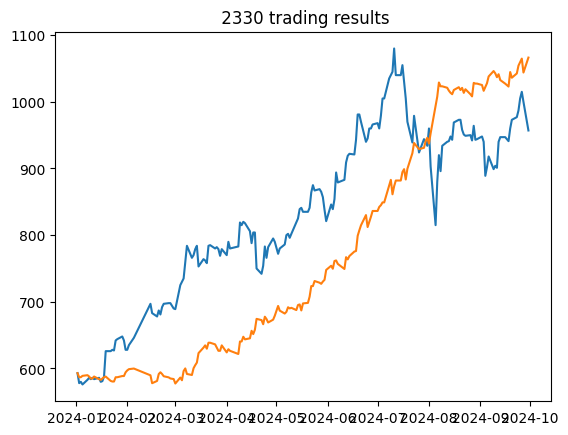

2317 鴻海 tw


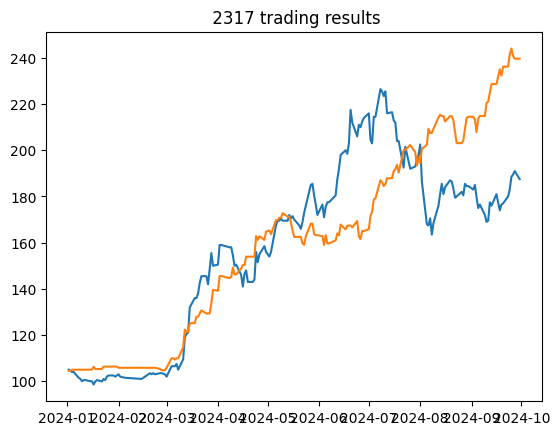

2454 聯發科 tw


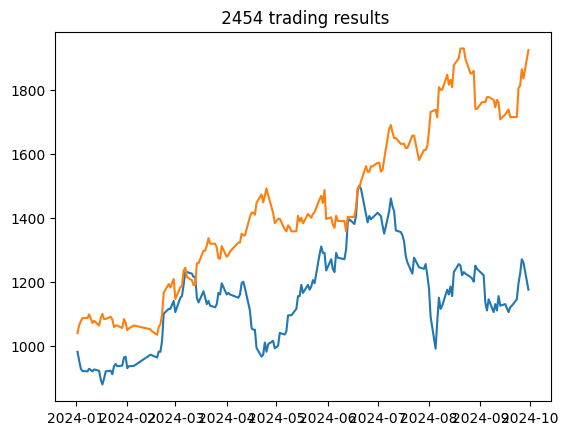

2382 廣達 tw


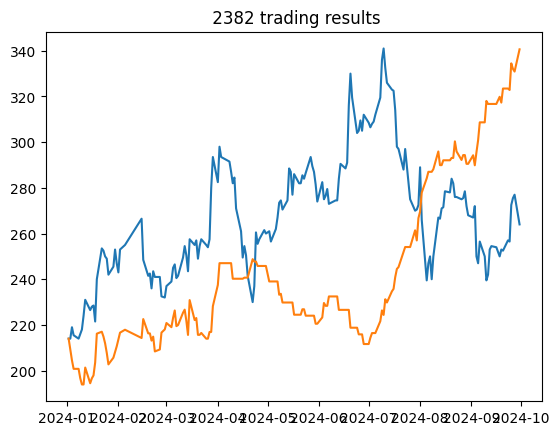

3231 緯創 tw


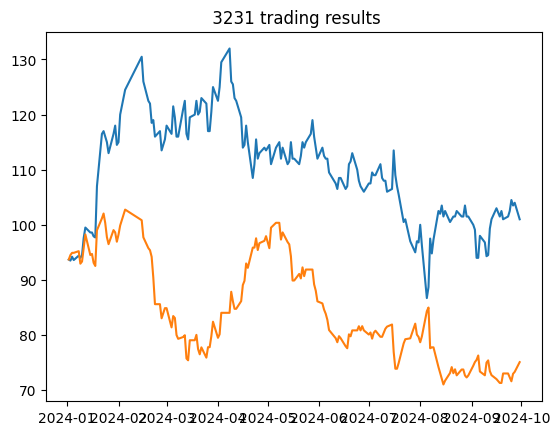

AAPL Apple Inc. us


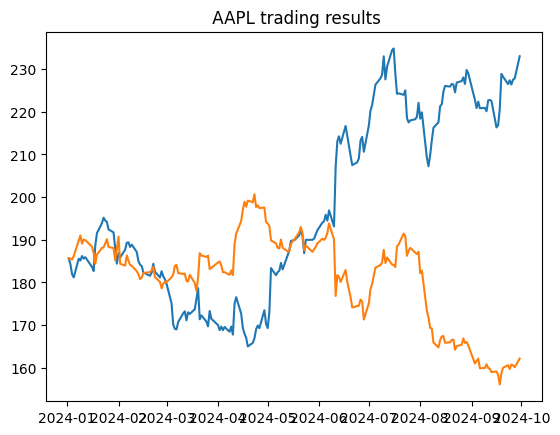

GOOGL Google us


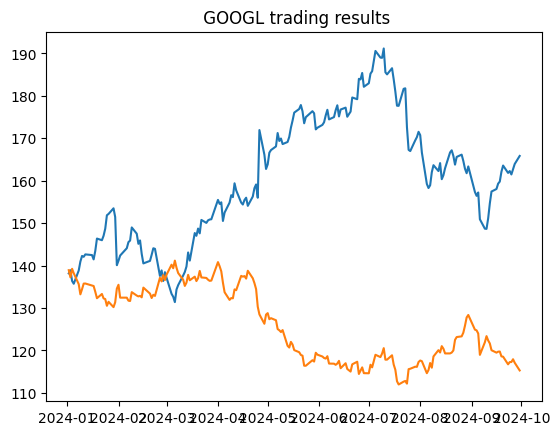

MSFT Microsoft us


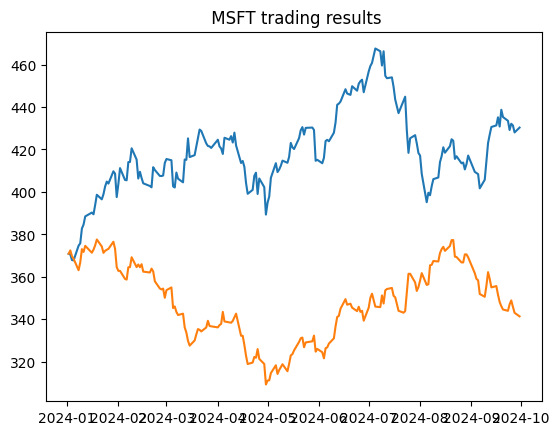

AMZN Amazon inc. us


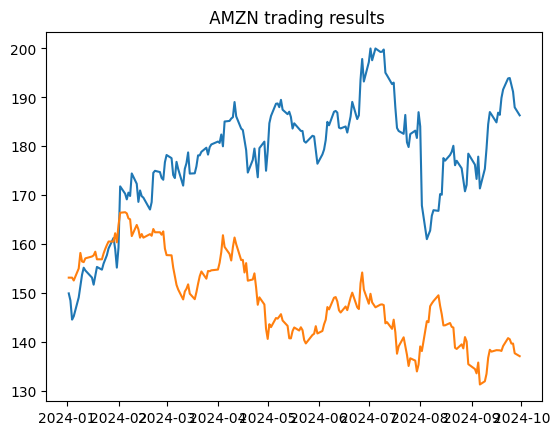

TSLA Tesla us


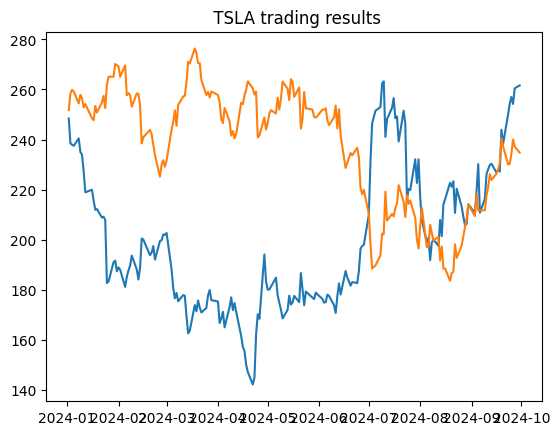

NVDA Nvidia us


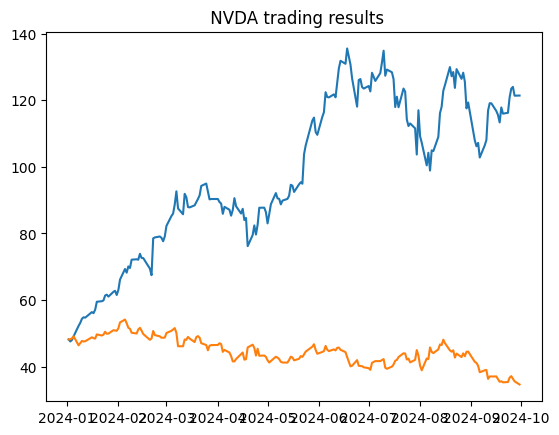

In [6]:
for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }
    print(env['stock_id'], env['stock_name'], env['country'])
    stock_factor = StockFactor(env)
    stock_factor.plot_acumulated_return(date_ranges=date_ranges)

# Factor embedding

In [ ]:
from factor_embd import FactorEmb

for stock in data:
    for date_r in  date_ranges:
        env = {
            "stock_id" : stock[0],
            "stock_name" : stock[1],
            "country" : stock[2],
            "start_date": date_r[0],
            "end_date": date_r[1],
        }

        print(env['stock_id'], env['stock_name'], env['country'])


        factor_embd = FactorEmb(env)
        factor_embd.generate_factors(llm4o)
        factor_embd.expand_factors(llm_factors=llm)
        train_datarange, test_datarange = factor_embd.split_exp()

        re_run = False # 是否重新訓練，True:刪除原有資料
        mode = 0
        df = factor_embd.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
        display(df)
        mode = 1
        df = factor_embd.run_taining(mode, train_datarange, test_datarange, re_run=re_run)
        display(df)

        factor_embd.plot_acumulated_return()


## 顯示所有

In [20]:
import os
import json
import pandas as pd

for date_r in  date_ranges:
    env = {
        "start_date": date_r[0],
        "end_date": date_r[1],
    }

    path_out = f"out_stock/Embd_{env['start_date']}_{env['end_date']}/"
    skip_files = {"ac","factors_eng.json", "factors.json", "old_expand", ".DS_Store", "factors.json", "factors1.json", "embeddings.json", "expand.json", "expand1.json", "expand2.json", "clustered_summaries.json"}

    results = []
    index = []

    for folder in os.listdir(path_out):
        if folder in skip_files:
            continue
        folder_path = os.path.join(path_out, folder)
        for file in os.listdir(folder_path):
            if file in skip_files:
                continue
            path = os.path.join(folder_path, file, "result.json")
            with open(path, 'r') as f:
                json_data = json.load(f)

            results.append(json_data['test'])
            index.append(f"{folder}_{file}")

    df = pd.DataFrame(results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev',
                        'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱

    # 計算平均值
    average_row = df[['accuracy', 'precision', 'ev', 'precision_ev']].replace('%', '', regex=True).astype(float).mean()
    df['accuracy'] = df['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df['precision'] = df['precision'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected = df.loc[:, selected_columns]
    df_sorted = df_selected.sort_index()

    display(df_sorted)
    display(average_row)

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,47.27%,47.06%,0.003844,0.003989,55,24,27,2,2
2330_ev,55.56%,48.84%,0.001840,0.000877,54,21,22,9,2
2382_ev,48.21%,48.15%,-0.000266,-0.000734,56,26,28,1,1
2454_ev,51.02%,60.00%,0.003264,0.018223,49,3,2,22,22
3231_ev,42.86%,42.59%,-0.003028,-0.003603,56,23,31,1,1
AAPL_ev,51.67%,46.67%,0.000030,0.000191,60,14,16,17,13
AMZN_ev,58.33%,61.22%,0.002127,0.002495,60,30,19,5,6
GOOGL_ev,46.67%,60.00%,0.000616,0.002773,60,9,6,19,26
MSFT_ev,46.67%,0.00%,-0.001208,0.000000,60,0,2,28,30
NVDA_ev,51.72%,55.32%,-0.001179,0.001215,58,26,21,4,7


accuracy        0.502291
precision       0.465012
ev              0.000637
precision_ev    0.002203
dtype: float64

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,50.00%,50.00%,0.004870,0.005682,52,20,20,6,6
2330_ev,57.38%,55.56%,0.003375,0.003820,61,20,16,15,10
2382_ev,41.67%,42.86%,-0.002021,-0.001874,60,24,32,1,3
2454_ev,49.18%,46.94%,0.002639,0.001166,61,23,26,7,5
3231_ev,32.20%,27.78%,-0.004169,-0.005881,59,15,39,4,1
AAPL_ev,51.61%,48.00%,-0.000749,-0.000308,62,24,26,8,4
AMZN_ev,49.21%,50.94%,-0.000629,-0.000498,63,27,26,4,6
GOOGL_ev,57.14%,66.67%,0.001097,0.002664,63,32,16,4,11
MSFT_ev,59.26%,63.33%,0.000896,0.000148,54,19,11,13,11
NVDA_ev,40.98%,46.51%,-0.003350,-0.003102,61,20,23,5,13


accuracy        0.488921
precision       0.489622
ev             -0.000002
precision_ev   -0.000231
dtype: float64

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2317_ev,48.39%,45.10%,0.002523,0.000597,62,23,28,7,4
2330_ev,53.97%,52.17%,0.004052,0.003397,63,24,22,10,7
2382_ev,62.50%,0.00%,0.007509,0.000000,24,0,1,15,8
2454_ev,51.85%,44.44%,0.004221,0.006866,54,8,10,20,16
3231_ev,43.75%,23.81%,-0.003768,-0.006698,48,5,16,16,11
AAPL_ev,50.00%,56.52%,-0.001011,0.000426,64,26,20,6,12
AMZN_ev,37.70%,37.74%,-0.001791,-0.002251,61,20,33,3,5
GOOGL_ev,55.74%,52.17%,0.000852,-0.001091,61,24,22,10,5
MSFT_ev,55.17%,53.57%,0.000834,-0.000544,58,15,13,17,13
NVDA_ev,51.67%,51.16%,0.001188,-0.000380,60,22,21,9,8


accuracy        0.516865
precision       0.443746
ev              0.001274
precision_ev    0.000307
dtype: float64

2330 台積電 tw


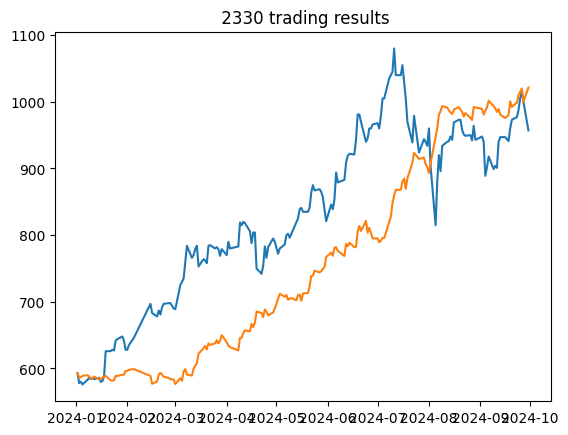

2317 鴻海 tw


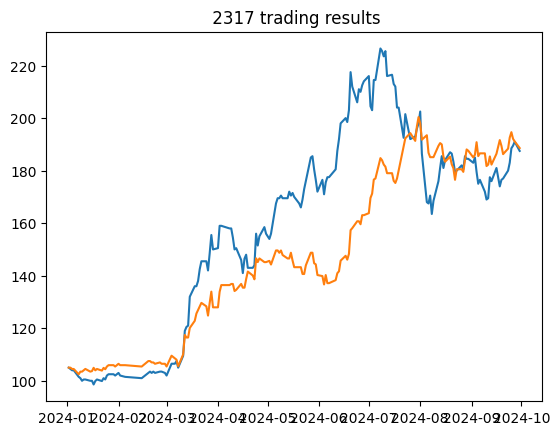

2454 聯發科 tw


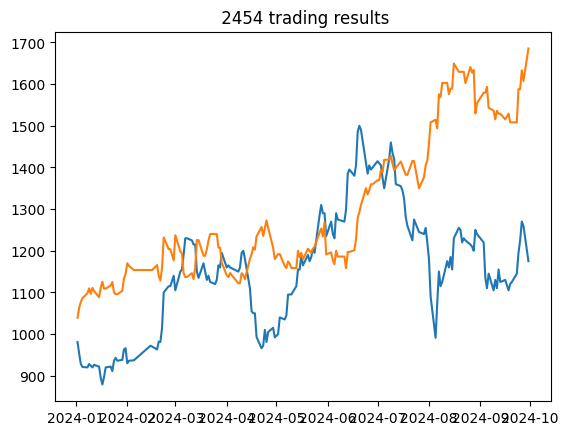

2382 廣達 tw


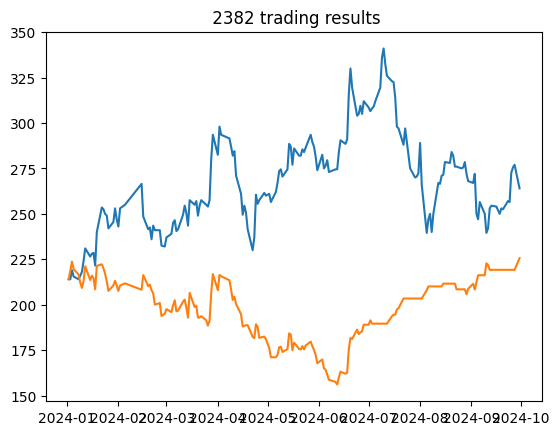

3231 緯創 tw


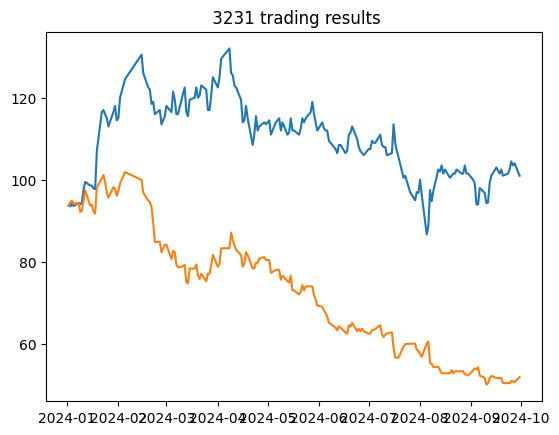

AAPL Apple Inc. us


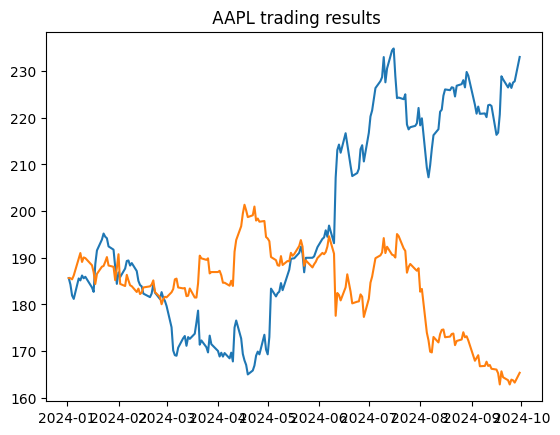

GOOGL Google us


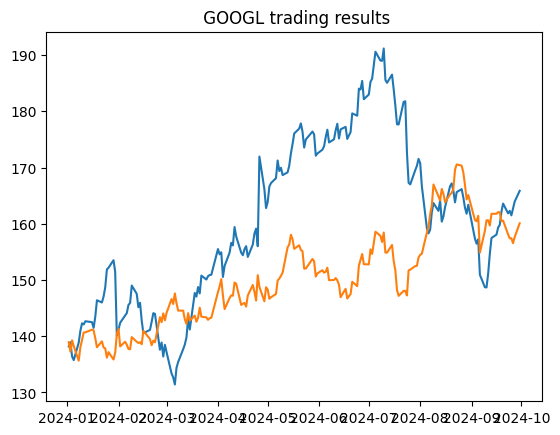

MSFT Microsoft us


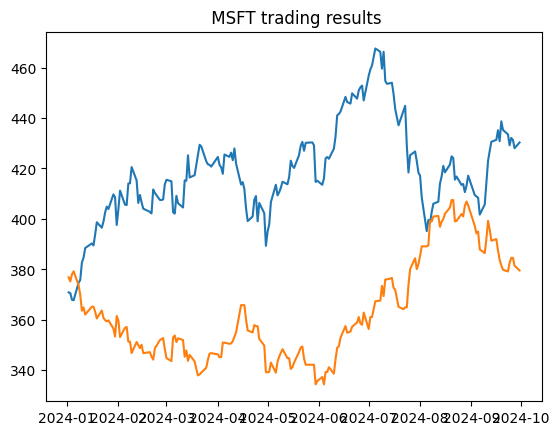

AMZN Amazon inc. us


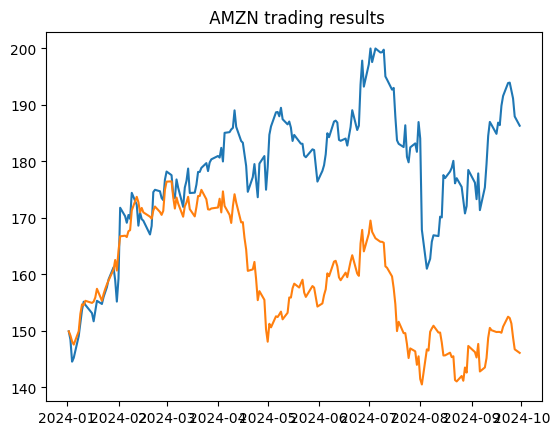

TSLA Tesla us


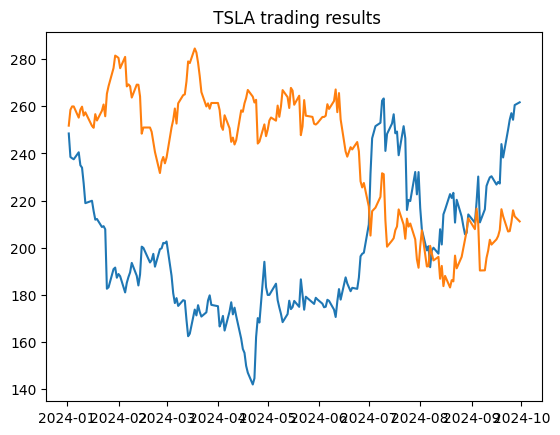

NVDA Nvidia us


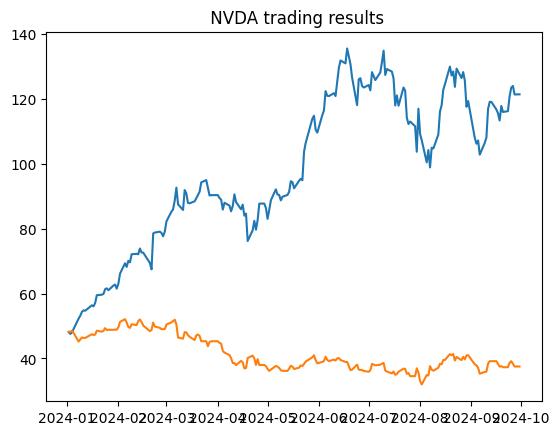

In [10]:
for stock in data:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20230401",
        "end_date" : "20240331",
    }
    print(env['stock_id'], env['stock_name'], env['country'])
    factor_embd = FactorEmb(env)
    factor_embd.plot_acumulated_return(date_ranges=date_ranges)